#### Create emotion_shift_narrative_injection_extended.csv append [title | article_content | comments_count]

In [1]:
import pandas as pd
import os

# --------------------------------------------------
# CONFIG
# --------------------------------------------------
BASE_DIR = "LT_datasets"
CURSOR_DIR = "C:/tf/cursor/results2_5-5/"

ARTICLE_SENTIMENT_FILE = CURSOR_DIR + "article_sentiment_scores_all.csv"
COMMENT_SENTIMENT_FILE = CURSOR_DIR + "comment_sentiment_scores_all.csv"
EMOTION_SHIFT_FILE = CURSOR_DIR + "emotion_shift_narrative_injection.csv"

OUTPUT_EMOTION_SHIFT = CURSOR_DIR + "emotion_shift_narrative_injection_extended.csv"
OUTPUT_ARTICLE_SENTIMENT = CURSOR_DIR + "article_sentiment_scores_all_extended.csv"

PORTAL_FILES = {
    "15min": "15min_articles.csv",
    "alfa": "alfa_articles.csv",
    "delfi": "delfi_articles.csv",
    "respublika": "respublika_articles.csv",
    "tv3": "tv3_articles.csv"
}

# --------------------------------------------------
# LOAD COMMENT SENTIMENT FILE (STRICT DTYPES)
# --------------------------------------------------
comment_df = pd.read_csv(
    COMMENT_SENTIMENT_FILE,
    dtype={
        "portal": "string",
        "article_id": "string",
        "comment_id": "string",
        "sentiment_score": "float",
        "neg": "float",
        "neu": "float",
        "pos": "float",
    },
    low_memory=False
)

# Normalize keys
comment_df["portal"] = comment_df["portal"].str.lower().str.strip()
comment_df["article_id"] = comment_df["article_id"].str.strip()
comment_df["comment_id"] = comment_df["comment_id"].str.strip()

# --------------------------------------------------
# AGGREGATE COMMENT SENTIMENTS (MEAN PER ARTICLE)
# --------------------------------------------------
comment_sentiment_agg = (
    comment_df
    .groupby(["portal", "article_id"], as_index=False)
    .agg(
        sentiment_score_mean=("sentiment_score", "mean"),
        neg_mean=("neg", "mean"),
        neu_mean=("neu", "mean"),
        pos_mean=("pos", "mean")
    )
)

# ==================================================
# PART 1: ARTICLE SENTIMENT → EXTENDED
# ==================================================
article_df = pd.read_csv(
    ARTICLE_SENTIMENT_FILE,
    dtype={"portal": "string", "article_id": "string"}
)

article_df["portal"] = article_df["portal"].str.lower().str.strip()
article_df["article_id"] = article_df["article_id"].str.strip()

article_extended_df = article_df.merge(
    comment_sentiment_agg,
    on=["portal", "article_id"],
    how="left"
)

article_extended_df.to_csv(OUTPUT_ARTICLE_SENTIMENT, index=False)
print(f"Saved: {OUTPUT_ARTICLE_SENTIMENT}")
print("Rows:", len(article_extended_df))

# ==================================================
# PART 2: EMOTION SHIFT → EXTENDED
# ==================================================
df = pd.read_csv(
    EMOTION_SHIFT_FILE,
    dtype={
        "portal": "string",
        "article_id": "string",
        "injection_comment_id": "string"
    }
)

df["portal"] = df["portal"].str.lower().str.strip()
df["article_id"] = df["article_id"].str.strip()
df["injection_comment_id"] = df["injection_comment_id"].str.strip()

# Article-level placeholders
df["title"] = ""
df["article_content"] = ""
df["comments_count"] = pd.NA
df["article_sentiment_score"] = pd.NA

# Comment-level aggregates
df["sentiment_score_mean"] = pd.NA
df["neg_mean"] = pd.NA
df["neu_mean"] = pd.NA
df["pos_mean"] = pd.NA

# --------------------------------------------------
# LOAD ARTICLE FILES (CACHE)
# --------------------------------------------------
article_dfs = {}
for portal, file_name in PORTAL_FILES.items():
    path = os.path.join(BASE_DIR, file_name)
    if os.path.exists(path):
        tmp = pd.read_csv(path, dtype={"article_id": "string"})
        tmp["article_id"] = tmp["article_id"].str.strip()
        article_dfs[portal] = tmp

# --------------------------------------------------
# ARTICLE + COMMENT AGGREGATE ENRICHMENT
# --------------------------------------------------
for idx, row in df.iterrows():
    portal = row["portal"]
    article_id = row["article_id"]

    if portal in article_dfs:
        match = article_dfs[portal].loc[
            article_dfs[portal]["article_id"] == article_id
        ]
        if not match.empty:
            df.at[idx, "title"] = match.iloc[0].get("title", "")
            df.at[idx, "article_content"] = match.iloc[0].get("article_content", "")
            df.at[idx, "comments_count"] = match.iloc[0].get("comments_count", pd.NA)

    art = article_df[
        (article_df["portal"] == portal) &
        (article_df["article_id"] == article_id)
    ]
    if not art.empty:
        df.at[idx, "article_sentiment_score"] = art.iloc[0]["article_sentiment_score"]

    agg = comment_sentiment_agg[
        (comment_sentiment_agg["portal"] == portal) &
        (comment_sentiment_agg["article_id"] == article_id)
    ]
    if not agg.empty:
        df.at[idx, "sentiment_score_mean"] = agg.iloc[0]["sentiment_score_mean"]
        df.at[idx, "neg_mean"] = agg.iloc[0]["neg_mean"]
        df.at[idx, "neu_mean"] = agg.iloc[0]["neu_mean"]
        df.at[idx, "pos_mean"] = agg.iloc[0]["pos_mean"]

# --------------------------------------------------
# INJECTION COMMENT SENTIMENT (SAFE VECTOR MERGE)
# --------------------------------------------------
comment_lookup = comment_df.rename(columns={
    "comment_id": "injection_comment_id",
    "sentiment_score": "injection_sentiment_score",
    "neg": "injection_neg",
    "neu": "injection_neu",
    "pos": "injection_pos"
})[
    [
        "portal", "article_id", "injection_comment_id",
        "injection_sentiment_score",
        "injection_neg", "injection_neu", "injection_pos"
    ]
]

df = df.merge(
    comment_lookup,
    on=["portal", "article_id", "injection_comment_id"],
    how="left"
)

# --------------------------------------------------
# SAVE
# --------------------------------------------------
df.to_csv(OUTPUT_EMOTION_SHIFT, index=False)
print(f"Saved: {OUTPUT_EMOTION_SHIFT}")
print("Rows:", len(df))
print(
    "Missing injection sentiment:",
    df["injection_sentiment_score"].isna().mean()
)

Saved: C:/tf/cursor/results2_5-5/article_sentiment_scores_all_extended.csv
Rows: 14340
Saved: C:/tf/cursor/results2_5-5/emotion_shift_narrative_injection_extended.csv
Rows: 2229
Missing injection sentiment: 0.0


In [4]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# FZ = 12

# INPUT_CSV = CURSOR_DIR + "emotion_shift_narrative_injection_extended.csv"

# # --------------------------------------------------
# # LOAD DATA
# # --------------------------------------------------
# df = pd.read_csv(INPUT_CSV)

# # Ensure numeric
# for col in [
#     "article_sentiment_score",
#     "injection_sentiment_score",
#     "sentiment_score_mean"
# ]:
#     df[col] = pd.to_numeric(df[col], errors="coerce")

# # --------------------------------------------------
# # DELTA SENTIMENT
# # --------------------------------------------------
# df["delta_sentiment"] = (
#     df["injection_sentiment_score"] - df["article_sentiment_score"]
# )

# print("Rows:", len(df))
# print("Mean Δ sentiment:", df["delta_sentiment"].mean())
# print("Median Δ sentiment:", df["delta_sentiment"].median())

# plt.figure(figsize=(9, 4))

# sns.histplot(
#     df["delta_sentiment"].dropna(),
#     bins=80,
#     kde=True,
#     color="purple",
#     alpha=0.6
# )

# plt.axvline(0, color="black", linestyle="--", linewidth=1)

# plt.xlabel("Δ Sentiment (Injection − Article)", fontsize=FZ + 2)
# plt.ylabel("Count", fontsize=FZ + 2)
# plt.title("Distribution of Injection-Induced Sentiment Shift", fontsize=FZ + 2)

# plt.tick_params(axis="x", labelsize=FZ)
# plt.tick_params(axis="y", labelsize=FZ)
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

Rows used for correlation: 2229

Pearson correlation:
                           article_sentiment_score  injection_sentiment_score  \
article_sentiment_score                   1.000000                   0.129537   
injection_sentiment_score                 0.129537                   1.000000   
sentiment_score_mean                      0.279934                   0.361952   

                           sentiment_score_mean  
article_sentiment_score                0.279934  
injection_sentiment_score              0.361952  
sentiment_score_mean                   1.000000  

Spearman correlation:
                           article_sentiment_score  injection_sentiment_score  \
article_sentiment_score                   1.000000                   0.126170   
injection_sentiment_score                 0.126170                   1.000000   
sentiment_score_mean                      0.267891                   0.272588   

                           sentiment_score_mean  
article_sentiment_score

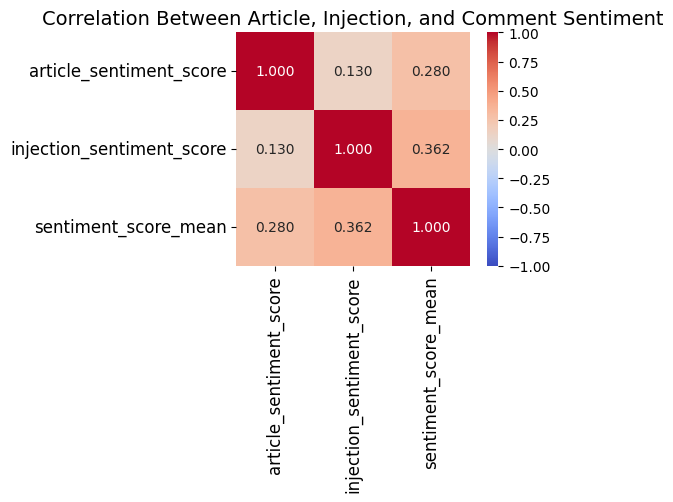

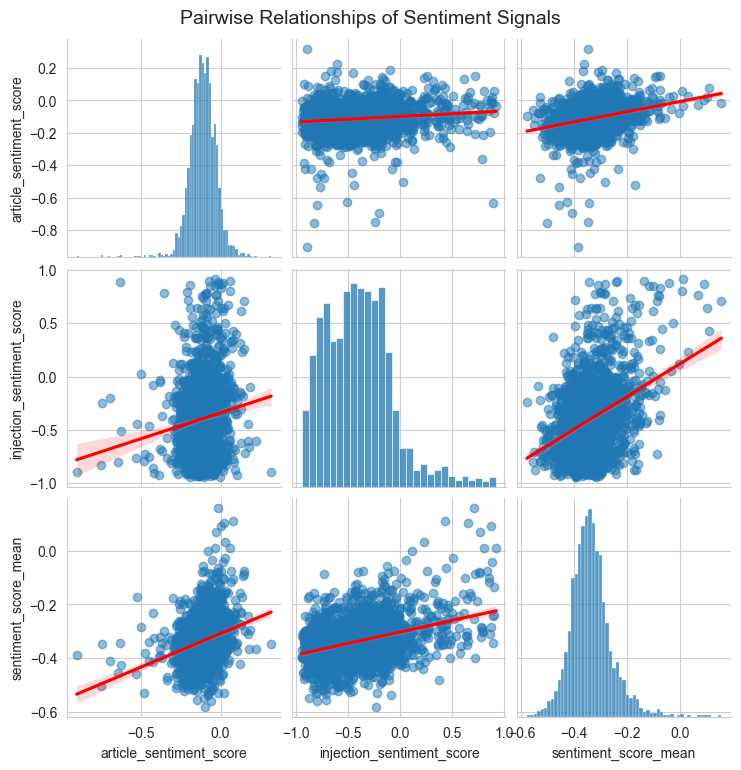

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FZ = 12

INPUT_CSV = CURSOR_DIR + "emotion_shift_narrative_injection_extended.csv"

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
df = pd.read_csv(INPUT_CSV)

cols = [
    "article_sentiment_score",
    "injection_sentiment_score",
    "sentiment_score_mean"
]

# Ensure numeric
for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

corr_df = df[cols].dropna()

print("Rows used for correlation:", len(corr_df))

# --------------------------------------------------
# CORRELATION VALUES
# --------------------------------------------------
pearson_corr = corr_df.corr(method="pearson")
spearman_corr = corr_df.corr(method="spearman")

print("\nPearson correlation:")
print(pearson_corr)

print("\nSpearman correlation:")
print(spearman_corr)

# --------------------------------------------------
# HEATMAP (PAPER READY)
# --------------------------------------------------
plt.figure(figsize=(6, 5))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Correlation Between Article, Injection, and Comment Sentiment", fontsize=FZ + 2)
plt.xticks(fontsize=FZ)
plt.yticks(fontsize=FZ)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# PAIRWISE RELATIONSHIPS (SCATTER + REGRESSION)
# --------------------------------------------------
sns.set_style("whitegrid")

pair = sns.pairplot(
    corr_df,
    kind="reg",
    plot_kws={"line_kws": {"color": "red"}, "scatter_kws": {"alpha": 0.5}}
)

pair.fig.suptitle(
    "Pairwise Relationships of Sentiment Signals",
    fontsize=FZ + 2,
    y=1.02
)

plt.show()

Rows used: 2229


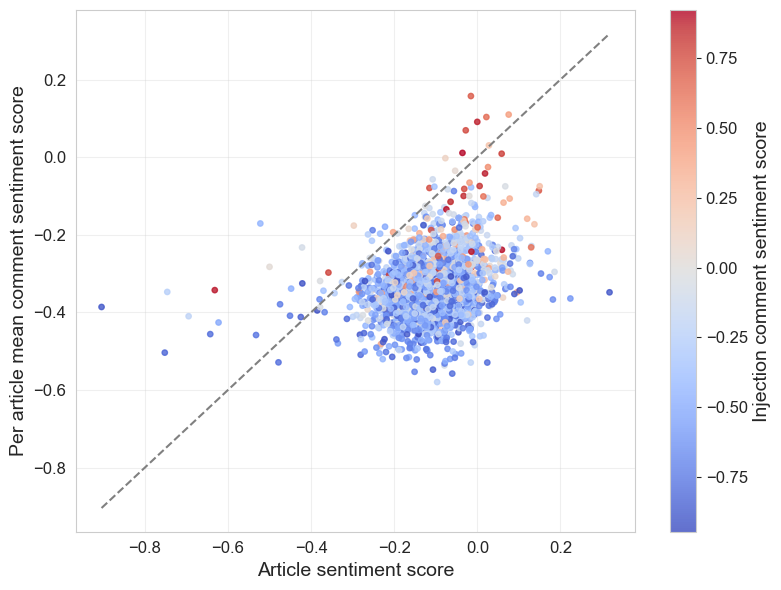

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

FZ = 12

INPUT_CSV = CURSOR_DIR + "emotion_shift_narrative_injection_extended.csv"

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
df = pd.read_csv(INPUT_CSV)

cols = [
    "article_sentiment_score",
    "sentiment_score_mean",
    "injection_sentiment_score"
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

plot_df = df[cols].dropna()

print("Rows used:", len(plot_df))

# --------------------------------------------------
# SCATTER
# --------------------------------------------------
plt.figure(figsize=(8, 6))

norm = Normalize(
    vmin=plot_df["injection_sentiment_score"].min(),
    vmax=plot_df["injection_sentiment_score"].max()
)

sc = plt.scatter(
    plot_df["article_sentiment_score"], # article_sentiment_score
    plot_df["sentiment_score_mean"],
    c=plot_df["injection_sentiment_score"], # injection_sentiment_score
    cmap="coolwarm",
    s=15,
    norm=norm,
    alpha=0.8
)

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label("Injection comment sentiment score", fontsize=FZ+2)
cbar.ax.tick_params(labelsize=FZ)

# Reference alignment line y = x
min_val = min(
    plot_df["article_sentiment_score"].min(),
    plot_df["sentiment_score_mean"].min()
)
max_val = max(
    plot_df["article_sentiment_score"].max(),
    plot_df["sentiment_score_mean"].max()
)

plt.plot([min_val, max_val], [min_val, max_val], "--", color="gray")

# Labels
plt.xlabel("Article sentiment score", fontsize=FZ + 2)
plt.ylabel("Per article mean comment sentiment score", fontsize=FZ + 2)
# plt.title("Article vs Comment Sentiment (Color = Injection Sentiment)", fontsize=FZ + 2)
plt.xticks(fontsize=FZ)
plt.yticks(fontsize=FZ)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Rows used: 2229


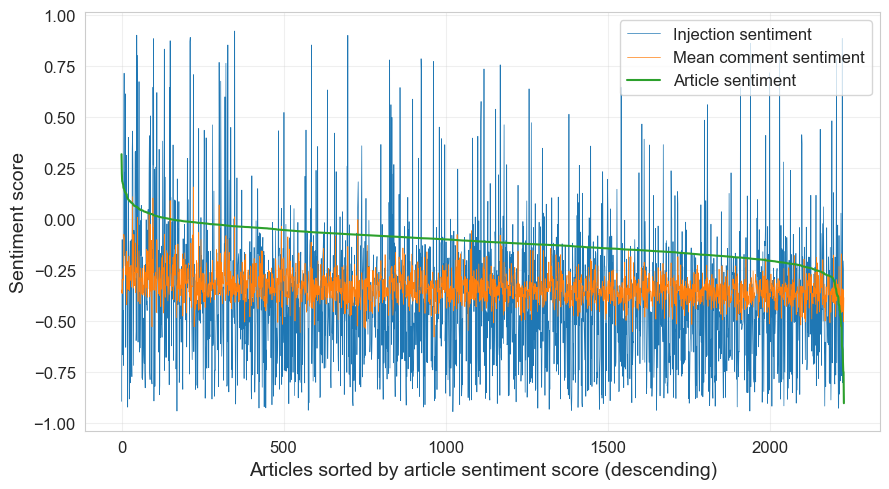

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

FZ = 12

INPUT_CSV = CURSOR_DIR + "emotion_shift_narrative_injection_extended.csv"

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
df = pd.read_csv(INPUT_CSV)

cols = [
    "article_sentiment_score",
    "sentiment_score_mean",
    "injection_sentiment_score"
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

plot_df = df[cols].dropna()

# --------------------------------------------------
# SORT BY ARTICLE SENTIMENT (DESC)
# --------------------------------------------------
plot_df = plot_df.sort_values(
    by="article_sentiment_score", # article_sentiment_score
    ascending=False
).reset_index(drop=True)

x = np.arange(len(plot_df))

print("Rows used:", len(plot_df))

# --------------------------------------------------
# LINE PLOT
# --------------------------------------------------
plt.figure(figsize=(9, 5))

plt.plot(
    x,
    plot_df["injection_sentiment_score"],
    label="Injection sentiment",
    linewidth=0.5
)

plt.plot(
    x,
    plot_df["sentiment_score_mean"],
    label="Mean comment sentiment",
    linewidth=0.5
)

plt.plot(
    x,
    plot_df["article_sentiment_score"],
    label="Article sentiment",
    linewidth=1.5
)

plt.xlabel(
    "Articles sorted by article sentiment score (descending)",
    fontsize=FZ + 2
)

plt.ylabel("Sentiment score", fontsize=FZ + 2)

# plt.title(
#     "Sentiment Alignment: Article vs Comments vs Injection",
#     fontsize=FZ + 3
# )

plt.tick_params(axis="x", labelsize=FZ)
plt.tick_params(axis="y", labelsize=FZ)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=FZ)

plt.tight_layout()
plt.show()

#### Print 10 highest and 10 lowest values with titles

In [5]:
import pandas as pd

# --------------------------------------------------
# LOAD FILE
# --------------------------------------------------
FILE = CURSOR_DIR + "emotion_shift_narrative_injection_extended.csv"
df = pd.read_csv(FILE)

# Column to sort by: "delta_after_minus_before" | "after" | "before"
my_col = "delta_after_minus_before"
top_N = 10

# --------------------------------------------------
# CHECK REQUIRED COLUMNS
# --------------------------------------------------
required_cols = [
    "title",
    "after",
    "before",
    "delta_after_minus_before"
]

for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# --------------------------------------------------
# CLEAN DATA
# --------------------------------------------------
df_clean = df.dropna(subset=required_cols)

# --------------------------------------------------
# TOP 10 HIGHEST VALUES
# --------------------------------------------------
print(f"\n=== TOP 10 HIGHEST by {my_col} ===\n")

top_10 = df_clean.sort_values(
    my_col, ascending=False
).head(top_N)

for _, row in top_10.iterrows():
    print(
        f"{row['after']:.4f} | "
        f"{row['before']:.4f} | "
        f"{row['delta_after_minus_before']:.4f} | "
        f"{row['title']}"
    )

# --------------------------------------------------
# TOP 10 LOWEST VALUES
# --------------------------------------------------
print(f"\n=== TOP 10 LOWEST by {my_col} ===\n")

bottom_10 = df_clean.sort_values(
    my_col, ascending=True
).head(top_N)

for _, row in bottom_10.iterrows():
    print(
        f"{row['after']:.4f} | "
        f"{row['before']:.4f} | "
        f"{row['delta_after_minus_before']:.4f} | "
        f"{row['title']}"
    )


=== TOP 10 HIGHEST by delta_after_minus_before ===


=== TOP 10 LOWEST by delta_after_minus_before ===



#### emotion–engagement coupling: comments_count vs delta_after_minus_before

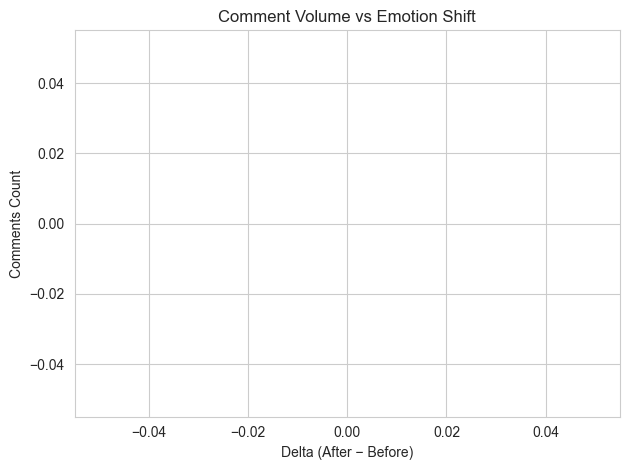

ValueError: Cannot cut empty array

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# LOAD FILE
# --------------------------------------------------
FILE = CURSOR_DIR + "emotion_shift_narrative_injection_extended.csv"
df = pd.read_csv(FILE)

# Column to sort by: "delta_after_minus_before" | "after" | "before"
my_col = "delta_after_minus_before"

# Ensure required columns exist
required_cols = ["comments_count", my_col]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# Clean data
df = df.dropna(subset=["comments_count", my_col])
df = df[df["comments_count"] >= 0]

# --------------------------------------------------
# 1) ROTATED SCATTER PLOT
# X: delta_after_minus_before
# Y: comments_count
# --------------------------------------------------
plt.figure()
plt.scatter(
    df[my_col],
    df["comments_count"],
    alpha=0.5
)

plt.xlabel("Delta (After − Before)")
plt.ylabel("Comments Count")
plt.title("Comment Volume vs Emotion Shift")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2) BAR PLOT — AVERAGED DISTRIBUTION
# (Bin delta and average comments_count)
# --------------------------------------------------
NUM_BINS = 20

df["delta_bin"] = pd.cut(
    df[my_col],
    bins=NUM_BINS
)

avg_comments = (
    df.groupby("delta_bin")["comments_count"]
    .mean()
    .reset_index()
)

# Bin centers for plotting
bin_centers = avg_comments["delta_bin"].apply(
    lambda x: x.mid
)

plt.figure()
plt.bar(
    bin_centers,
    avg_comments["comments_count"],
    width=(bin_centers.max() - bin_centers.min()) / NUM_BINS
)

plt.xlabel("Delta (After − Before)")
plt.ylabel("Average Comments Count")
plt.title("Average Comment Volume by Emotion Shift")
plt.tight_layout()
plt.show()

#### Before vs After Emotion Shift

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
FILE = CURSOR_DIR + "emotion_shift_narrative_injection_extended.csv"
df = pd.read_csv(FILE)

# Required columns
# portal	article_id	injection_comment_id	after	before	delta_after_minus_before	injection_total_reactions	article_total_reactions	
# title	article_content	comments_count	article_sentiment_score	sentiment_score_mean	neg_mean	neu_mean	pos_mean
# injection_sentiment_score	injection_neg	injection_neu	injection_pos
filter_col = "injection_sentiment_score"

cols = ["before", "after", filter_col]
df = df.dropna(subset=cols)

# Optional: sample if very large
MAX_POINTS = 5000
if len(df) > MAX_POINTS:
    df = df.sample(MAX_POINTS, random_state=42)

plt.figure(figsize=(8, 6)) # 6 5

sc = plt.scatter(
    df["before"],
    df["after"],
    c=df[filter_col],
    # norm=LogNorm(),
    cmap="viridis", # "hot" "coolwarm" "RdBu_r" "jet" "viridis"
    # vmin=-0.6,
    # vmax=0.6,
    s=10,
    alpha=0.9
)
# Colorbar
cbar = plt.colorbar(sc)

# Diagonal line (no change reference)
min_val = min(df["before"].min(), df["after"].min())
max_val = max(df["before"].max(), df["after"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="gray")

plt.xlabel("Before Emotion")
plt.ylabel("After Emotion")
plt.title("Before vs After Emotion Shift")

plt.tight_layout()
plt.show()
len(df[filter_col])

#### LLM based. What semantic properties of articles explain the direction of emotion shift? 
#### title + content → sentence embeddings → clustering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
FILE = CURSOR_DIR + "emotion_shift_narrative_injection_extended.csv"
df = pd.read_csv(FILE)

required_cols = [
    "before", "after", "delta_after_minus_before",
    "title", "article_content"
]

df = df.dropna(subset=required_cols)

# Combine title + content
df["text"] = (
    df["title"].astype(str) + ". " +
    df["article_content"].astype(str)
)

# Optional: limit for speed
MAX_DOCS = 5000
if len(df) > MAX_DOCS:
    df = df.sample(MAX_DOCS, random_state=42)

# --------------------------------------------------
# SEMANTIC EMBEDDINGS (MULTILINGUAL)
# --------------------------------------------------
model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

embeddings = model.encode(
    df["text"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

# --------------------------------------------------
# CLUSTER ARTICLES BY SEMANTIC TOPIC
# --------------------------------------------------
N_CLUSTERS = 5

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10
)

df["topic_cluster"] = kmeans.fit_predict(embeddings)

# --------------------------------------------------
# CLUSTER-LEVEL EMOTION SHIFT SUMMARY
# --------------------------------------------------
summary = (
    df.groupby("topic_cluster")
    .agg(
        articles=("article_id", "count"),
        mean_before=("before", "mean"),
        mean_after=("after", "mean"),
        mean_delta=("delta_after_minus_before", "mean")
    )
    .sort_values("mean_delta", ascending=False)
)

print("\n=== CLUSTER EMOTION SHIFT SUMMARY ===\n")
display(summary)

# --------------------------------------------------
# SHOW EXAMPLE TITLES PER CLUSTER (INTERPRETABLE!)
# --------------------------------------------------
print("\n=== SAMPLE TITLES PER CLUSTER ===\n")
for c in range(N_CLUSTERS):
    print(f"\nCluster {c} | mean delta = {summary.loc[c,'mean_delta']:.4f}")
    sample_titles = df[df["topic_cluster"] == c]["title"].head(5)
    for t in sample_titles:
        print(" •", t)

# --------------------------------------------------
# BEFORE vs AFTER PLOT (COLORED BY SEMANTIC CLUSTER)
# --------------------------------------------------
plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    df["before"],
    df["after"],
    c=df["topic_cluster"],
    alpha=0.75
)

# Diagonal reference line
min_val = min(df["before"].min(), df["after"].min())
max_val = max(df["before"].max(), df["after"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Before Emotion")
plt.ylabel("After Emotion")
plt.title("Before vs After Emotion Shift (Semantic Clusters, LT)")

plt.colorbar(scatter, label="Semantic Topic Cluster")
plt.tight_layout()
plt.show()

#### LLM based. What semantic properties of articles explain the direction of emotion shift?
#### Define a semantic anchor (war narrative)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

FZ = 12
# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
FILE = CURSOR_DIR + "emotion_shift_narrative_injection_extended.csv"
df = pd.read_csv(FILE)

required_cols = [
    "before", "after", "title", "article_content"
]
df = df.dropna(subset=required_cols)

# Combine title + content
df["text"] = (
    df["title"].astype(str) + ". " +
    df["article_content"].astype(str)
)

# Optional subsample for speed
MAX_DOCS = 5000
if len(df) > MAX_DOCS:
    df = df.sample(MAX_DOCS, random_state=42)

# --------------------------------------------------
# LOAD MULTILINGUAL EMBEDDING MODEL
# --------------------------------------------------
model = SentenceTransformer(
    # "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2" # small
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2" # same in lt_semantic_emotion_analysis_2_gpu.py -> "emotion_shift_narrative_injection.csv"
)

doc_embeddings = model.encode(
    df["text"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True
)

# --------------------------------------------------
# DEFINE WAR / GEOPOLITICS SEMANTIC ANCHOR
# --------------------------------------------------
war_anchor_text = (
    "conflict war invasion putin ukraine"
    # "love peace harmony friendliness"
    # "war conflict invasion ukraine"
    # "konfliktas karas nelaimė žūti sprogo mūšis"
    # "Lithuania power energy independence BRELL SGD terminalas LitPol Nord Pool"
)

anchor_embedding = model.encode(
    [war_anchor_text],
    normalize_embeddings=True
)

# --------------------------------------------------
# SEMANTIC SIMILARITY
# --------------------------------------------------
similarities = cosine_similarity(
    doc_embeddings,
    anchor_embedding
).flatten()

df["war_similarity"] = similarities

# Threshold: adjust if needed (0.25–0.35 works well)
THRESHOLD = 0.5
df["is_war_related"] = df["war_similarity"] >= THRESHOLD

print("\nWar-related articles:", df["is_war_related"].sum())
print("Non-war articles:", (~df["is_war_related"]).sum())

# --------------------------------------------------
# BEFORE vs AFTER PLOT (RED = WAR, BLUE = OTHER)
# --------------------------------------------------
plt.figure(figsize=(7, 6))

# Non-war articles
plt.scatter(
    df.loc[~df["is_war_related"], "before"],
    df.loc[~df["is_war_related"], "after"],
    alpha=0.6,
    label="Other topics"
)

# War-related articles
plt.scatter(
    df.loc[df["is_war_related"], "before"],
    df.loc[df["is_war_related"], "after"],
    alpha=0.8,
    label="Conflicts",
)

# Diagonal reference line
min_val = min(df["before"].min(), df["after"].min())
max_val = max(df["before"].max(), df["after"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Before sentiment", fontsize=FZ+2)
plt.ylabel("After sentiment", fontsize=FZ+2)
plt.xticks(fontsize=FZ)
plt.yticks(fontsize=FZ)
# plt.title("Before vs After Sentiment Shift\nConflict-Related vs Other Articles")

plt.legend(fontsize=FZ+2)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# NUMERICAL COMPARISON (IMPORTANT FOR PAPER)
# --------------------------------------------------
summary = (
    df.groupby("is_war_related")
    .agg(
        articles=("article_id", "count"),
        mean_before=("before", "mean"),
        mean_after=("after", "mean"),
        mean_delta=("after", lambda x: (x - df.loc[x.index, "before"]).mean())
    )
)

print("\n=== EMOTION SHIFT COMPARISON ===\n")
display(summary)

#### Lets you select which parameter controls coloring
##### injection_total_reactions
##### article_total_reactions
##### comments_count
#### Lets you set a custom threshold, Colors points in two colors based on that choice, Plots Before vs After Emotion Shift


Coloring by: comments_count
Threshold: 200
Above threshold: 0
Below threshold: 0


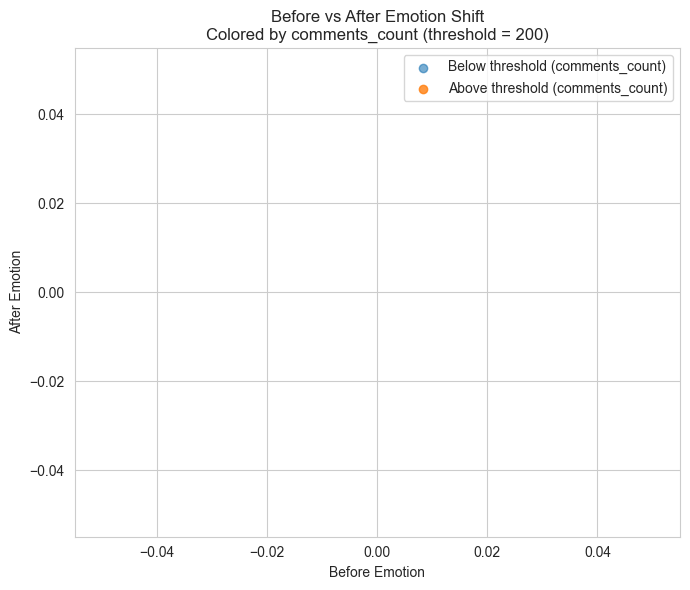

ValueError: Length mismatch: Expected axis has 0 elements, new values have 2 elements

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# USER SETTINGS (CHANGE THESE)
# --------------------------------------------------
FILE = CURSOR_DIR + "emotion_shift_narrative_injection_extended.csv"

COLOR_BY = "comments_count"
# options:
#   "injection_total_reactions"
#   "article_total_reactions"
#   "comments_count"

THRESHOLD = 200   # <-- adjust threshold here

HIGH_LABEL = "Above threshold"
LOW_LABEL = "Below threshold"

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
df = pd.read_csv(FILE)

required_cols = [
    "before", "after", "title",
    "injection_total_reactions",
    "article_total_reactions",
    "comments_count"
]

df = df.dropna(subset=required_cols)

if COLOR_BY not in df.columns:
    raise ValueError(f"Column '{COLOR_BY}' not found in CSV")

# --------------------------------------------------
# CREATE BINARY GROUP FOR COLORING
# --------------------------------------------------
df["highlight"] = df[COLOR_BY] >= THRESHOLD

print(f"\nColoring by: {COLOR_BY}")
print(f"Threshold: {THRESHOLD}")
print("Above threshold:", df["highlight"].sum())
print("Below threshold:", (~df["highlight"]).sum())

# --------------------------------------------------
# BEFORE vs AFTER EMOTION SHIFT PLOT
# --------------------------------------------------
plt.figure(figsize=(7, 6))

# Below threshold (blue)
plt.scatter(
    df.loc[~df["highlight"], "before"],
    df.loc[~df["highlight"], "after"],
    alpha=0.6,
    label=f"{LOW_LABEL} ({COLOR_BY})"
)

# Above threshold (red)
plt.scatter(
    df.loc[df["highlight"], "before"],
    df.loc[df["highlight"], "after"],
    alpha=0.8,
    label=f"{HIGH_LABEL} ({COLOR_BY})"
)

# Diagonal reference line
min_val = min(df["before"].min(), df["after"].min())
max_val = max(df["before"].max(), df["after"].max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color='gray',
    linewidth=1
)

plt.xlabel("Before Emotion")
plt.ylabel("After Emotion")
plt.title(
    "Before vs After Emotion Shift\n"
    f"Colored by {COLOR_BY} (threshold = {THRESHOLD})"
)

plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# NUMERICAL SUMMARY (FOR PAPER)
# --------------------------------------------------
summary = (
    df.groupby("highlight")
    .agg(
        articles=("article_id", "count"),
        mean_before=("before", "mean"),
        mean_after=("after", "mean"),
        mean_delta=("after", lambda x: (x - df.loc[x.index, "before"]).mean()),
        mean_selected_param=(COLOR_BY, "mean")
    )
)

summary.index = [
    f"{LOW_LABEL}",
    f"{HIGH_LABEL}"
]

print("\n=== EMOTION SHIFT COMPARISON ===\n")
display(summary)

#### What kinds of articles systematically amplify emotion, and what kinds do not?

In [11]:
import pandas as pd
import numpy as np
import re
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
FILE = CURSOR_DIR + "emotion_shift_narrative_injection_extended.csv"
DELTA_THRESHOLD = 0.2
MAX_DOCS = 5000
TOP_SENTENCES = 8   # how many summary sentences per group

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
df = pd.read_csv(FILE)

required_cols = [
    "delta_after_minus_before",
    "title",
    "article_content"
]
df = df.dropna(subset=required_cols)

df["text"] = (
    df["title"].astype(str) + ". " +
    df["article_content"].astype(str)
)

if len(df) > MAX_DOCS:
    df = df.sample(MAX_DOCS, random_state=42)

# --------------------------------------------------
# SPLIT GROUPS
# --------------------------------------------------
group_pos = df[df["delta_after_minus_before"] >  DELTA_THRESHOLD].copy()
group_neg = df[df["delta_after_minus_before"] < -DELTA_THRESHOLD].copy()

print(f"\nPositive shift articles: {len(group_pos)}")
print(f"Negative shift articles: {len(group_neg)}")

# --------------------------------------------------
# LOAD MULTILINGUAL MODEL
# --------------------------------------------------
model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
)

# --------------------------------------------------
# SENTENCE EXTRACTION FUNCTION
# --------------------------------------------------
def extract_sentences(text, min_len=40):
    sentences = re.split(r"[.!?]\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) >= min_len]

# --------------------------------------------------
# BUILD SENTENCE CORPORA
# --------------------------------------------------
def build_sentence_df(group_df):
    rows = []
    for _, row in group_df.iterrows():
        for sent in extract_sentences(row["text"]):
            rows.append({
                "article_id": row["article_id"],
                "delta": row["delta_after_minus_before"],
                "sentence": sent
            })
    return pd.DataFrame(rows)

sent_pos = build_sentence_df(group_pos)
sent_neg = build_sentence_df(group_neg)

print("\nPositive sentences:", len(sent_pos))
print("Negative sentences:", len(sent_neg))

# --------------------------------------------------
# EMBEDDINGS
# --------------------------------------------------
emb_pos = model.encode(
    sent_pos["sentence"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True
)

emb_neg = model.encode(
    sent_neg["sentence"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True
)

# --------------------------------------------------
# CENTROIDS
# --------------------------------------------------
centroid_pos = emb_pos.mean(axis=0, keepdims=True)
centroid_neg = emb_neg.mean(axis=0, keepdims=True)

centroid_similarity = cosine_similarity(
    centroid_pos, centroid_neg
)[0, 0]

print("\nSemantic similarity between POS and NEG groups:",
      round(centroid_similarity, 4))

# --------------------------------------------------
# REPRESENTATIVE SENTENCES (SUMMARY)
# --------------------------------------------------
sent_pos["similarity"] = cosine_similarity(
    emb_pos, centroid_pos
).flatten()

sent_neg["similarity"] = cosine_similarity(
    emb_neg, centroid_neg
).flatten()

print("\n=== SEMANTIC SUMMARY: POSITIVE EMOTION SHIFT ===\n")
for i, row in sent_pos.sort_values(
    "similarity", ascending=False
).head(TOP_SENTENCES).iterrows():
    print("•", row["sentence"])

print("\n=== SEMANTIC SUMMARY: NEGATIVE EMOTION SHIFT ===\n")
for i, row in sent_neg.sort_values(
    "similarity", ascending=False
).head(TOP_SENTENCES).iterrows():
    print("•", row["sentence"])


Positive shift articles: 0
Negative shift articles: 0

Positive sentences: 0
Negative sentences: 0


KeyError: 'sentence'

### Plots semantic similarity vs time since publication
##### User selects portal and article_id
##### Reads semantic_similarity_over_time_all.csv
##### Sorts comments historically over time
##### Uses comment time (created_at) but aligns it to article publication (delta_hours)
##### Produces a conference-ready time series plot

C:\Users\tom\AppData\Local\Temp\ipykernel_9004\1541398891.py:15: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FILE)


Comments plotted: 204
Article published at: 2026-01-18 05:00:00


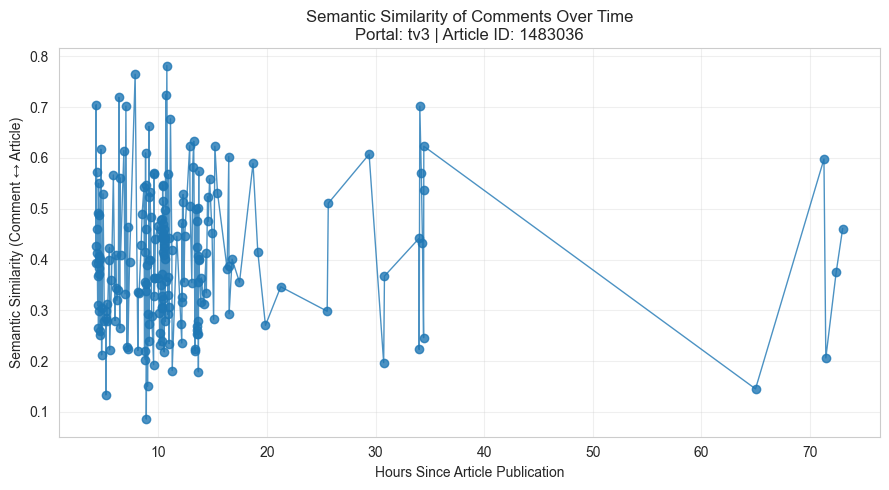

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# USER SELECTION
# --------------------------------------------------
FILE = CURSOR_DIR + "semantic_similarity_over_time_all.csv"

PORTAL = "tv3"        # <-- change
ARTICLE_ID = 1483036    # <-- change

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
df = pd.read_csv(FILE)

required_cols = [
    "portal",
    "article_id",
    "comment_id",
    "created_at",
    "published_at",
    "delta_hours",
    "semantic_similarity"
]

df = df.dropna(subset=required_cols)

# Parse timestamps
df["created_at"] = pd.to_datetime(df["created_at"])
df["published_at"] = pd.to_datetime(df["published_at"])

# --------------------------------------------------
# FILTER ARTICLE
# --------------------------------------------------
df_art = df[
    (df["portal"] == PORTAL) &
    (df["article_id"] == ARTICLE_ID)
].copy()

if df_art.empty:
    raise ValueError("No data found for selected portal/article_id")

# Sort chronologically
df_art = df_art.sort_values("created_at")

print(f"Comments plotted: {len(df_art)}")
print("Article published at:", df_art["published_at"].iloc[0])

# --------------------------------------------------
# PLOT SEMANTIC SIMILARITY OVER TIME
# --------------------------------------------------
plt.figure(figsize=(9, 5))

plt.plot(
    df_art["delta_hours"],
    df_art["semantic_similarity"],
    marker="o",
    linewidth=1,
    alpha=0.8
)

plt.xlabel("Hours Since Article Publication")
plt.ylabel("Semantic Similarity (Comment ↔ Article)")
plt.title(
    f"Semantic Similarity of Comments Over Time\n"
    f"Portal: {PORTAL} | Article ID: {ARTICLE_ID}"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Comments & Reactions Over Time Since Publication

Total comments: 292737
Total reactions: 4528000.0


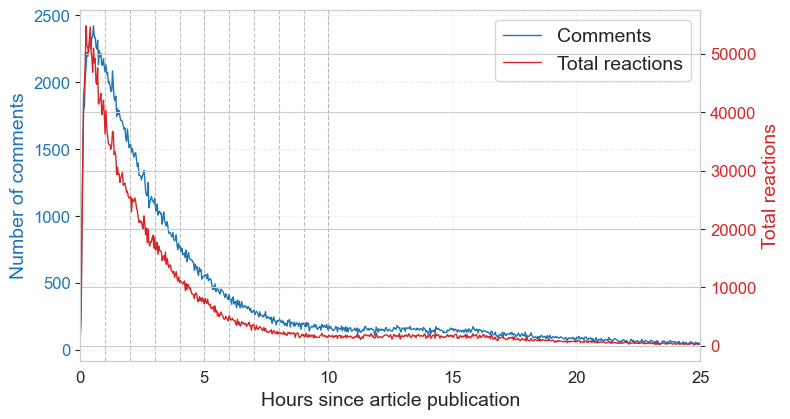

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
FZ = 12 # Font size

SEM_FILE = CURSOR_DIR + "semantic_similarity_over_time_all.csv"
REACT_FILE = CURSOR_DIR + "comment_sentiment_scores_all.csv"

TIME_BIN_HOURS = 1/30
X_MAX_HOURS = 25

# --------------------------------------------------
# LOAD FILES (With explicit types to prevent DtypeWarning)
# --------------------------------------------------
# Define which columns should be treated as strings to avoid mixed types
dtype_settings = {"comment_id": str}
sem_df = pd.read_csv(SEM_FILE, dtype=dtype_settings, low_memory=False)
react_df = pd.read_csv(REACT_FILE, dtype=dtype_settings, low_memory=False)
# # --------------------------------------------------
# # LOAD FILES
# # --------------------------------------------------
# sem_df = pd.read_csv(SEM_FILE)
# react_df = pd.read_csv(REACT_FILE)

# --------------------------------------------------
# CLEAN TIMESTAMPS
# --------------------------------------------------
sem_df["created_at"] = pd.to_datetime(sem_df["created_at"], errors="coerce")
sem_df["published_at"] = pd.to_datetime(sem_df["published_at"], errors="coerce")

react_df["total_reactions"] = pd.to_numeric(
    react_df["total_reactions"], errors="coerce"
).fillna(0)

# --------------------------------------------------
# KEEP REQUIRED COLUMNS
# --------------------------------------------------
sem_df = sem_df[["comment_id", "created_at", "published_at"]].dropna()
react_df = react_df[["comment_id", "total_reactions"]]

# Strip whitespace just in case the CSV has " 123" instead of "123"
sem_df["comment_id"] = sem_df["comment_id"].str.strip()
react_df["comment_id"] = react_df["comment_id"].str.strip()

# --------------------------------------------------
# MERGE FILES
# --------------------------------------------------
df = sem_df.merge(react_df, on="comment_id", how="left")
df["total_reactions"] = df["total_reactions"].fillna(0)

# --------------------------------------------------
# COMPUTE TIME SINCE PUBLICATION
# --------------------------------------------------
df["delta_hours"] = ((df["created_at"] - df["published_at"]).dt.total_seconds() / 3600)
df = df[df["delta_hours"] >= 0]

# --------------------------------------------------
# BIN TIME
# --------------------------------------------------
df["time_since_pub_bin"] = (df["delta_hours"] // TIME_BIN_HOURS) * TIME_BIN_HOURS

# --------------------------------------------------
# COMMENT & REACTION ACTIVITY
# --------------------------------------------------
comment_activity = (
    df.groupby("time_since_pub_bin")
    .size()
    .reset_index(name="comment_count")
    .sort_values("time_since_pub_bin")
)

reaction_activity = (
    df.groupby("time_since_pub_bin")["total_reactions"]
    .sum()
    .reset_index()
    .sort_values("time_since_pub_bin")
)

# --------------------------------------------------
# OPTIONAL TIME CUTOFF
# --------------------------------------------------
if X_MAX_HOURS is not None:
    comment_activity = comment_activity[comment_activity["time_since_pub_bin"] <= X_MAX_HOURS]
    reaction_activity = reaction_activity[reaction_activity["time_since_pub_bin"] <= X_MAX_HOURS]

print("Total comments:", comment_activity["comment_count"].sum())
print("Total reactions:", reaction_activity["total_reactions"].sum())

# --------------------------------------------------
# PLOT BOTH ON SINGLE PLOT WITH DUAL Y-AXIS & ONE LEGEND
# --------------------------------------------------
fig, ax1 = plt.subplots(figsize=(8,4.3))

# --- Comment activity ---
line1, = ax1.plot(
    comment_activity["time_since_pub_bin"],
    comment_activity["comment_count"],
    color="tab:blue",
    # marker="o",
    linewidth=1.0,
    label="Comments"
)
ax1.set_xlabel("Hours since article publication", fontsize=FZ+2)
ax1.set_ylabel("Number of comments", color="tab:blue", fontsize=FZ+2)
ax1.tick_params(axis="y", labelcolor="tab:blue", labelsize=FZ)
# ax1.grid(alpha=0.3)

# --- Keep existing grid ---
ax1.grid(which='major', axis='y', linestyle='--', alpha=0.3)  # existing y-grid
ax1.grid(which='major', axis='x', linestyle='-', alpha=0.2)   # optional main x-grid
# --- Add extra vertical lines at 1 to 10 hours ---
for hour in range(1, 11):
    ax1.axvline(x=hour, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax1.tick_params(axis="x", labelsize=FZ)

# --- Reaction activity on secondary y-axis ---
ax2 = ax1.twinx()
line2, = ax2.plot(
    reaction_activity["time_since_pub_bin"],
    reaction_activity["total_reactions"],
    color="tab:red",
    # marker="s",
    linewidth=1.0,
    label="Total reactions"
)
ax2.set_ylabel("Total reactions", color="tab:red", fontsize=FZ+2)
ax2.tick_params(axis="y", labelcolor="tab:red", labelsize=FZ)

# --- Titles ---
# fig.suptitle("Comments & Reactions Over Time Since Publication", fontsize=14)
ax1.set_xlim(0, X_MAX_HOURS)

# --- Combined legend ---
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right", fontsize=FZ+2)

plt.tight_layout()
plt.show()

#### New copy - comment_sentiment_scores_all_extended_ssot.csv
##### Reads the existing CSVs
##### Adds semantic_similarity by safe key-based merge
##### Writes a new file
##### Inserts NaN where no match exists
##### Does not modify the original files

In [14]:
import pandas as pd

# -----------------------------
# File paths (adjust if needed)
# -----------------------------
SENTIMENT_CSV = CURSOR_DIR + "comment_sentiment_scores_all.csv"
SIMILARITY_CSV = CURSOR_DIR + "semantic_similarity_over_time_all.csv"
OUTPUT_CSV = CURSOR_DIR + "comment_sentiment_scores_all_extended_ssot.csv"

# -----------------------------
# Load CSV files
# -----------------------------
sent_df = pd.read_csv(SENTIMENT_CSV)
sim_df = pd.read_csv(SIMILARITY_CSV)

print("Loaded:")
print(f"  Sentiment rows:  {len(sent_df):,}")
print(f"  Similarity rows: {len(sim_df):,}")

# -----------------------------
# Merge semantic similarity
# -----------------------------
extended_df = sent_df.merge(
    sim_df[
        [
            "portal",
            "article_id",
            "comment_id",
            "semantic_similarity"
        ]
    ],
    on=["portal", "article_id", "comment_id"],
    how="left"
)

# ------------------------------------------------
# Add flag: comment before article publication
# ------------------------------------------------
extended_df["comment_before_publication"] = (
    extended_df["semantic_similarity"].isna()
)

# -----------------------------
# Sanity checks
# -----------------------------
print("\nAfter merge:")
print(f"  Rows preserved: {len(extended_df):,}")

missing_sim = extended_df["semantic_similarity"].isna().sum()
print(f"  Rows with NaN semantic_similarity: {missing_sim:,}")

flagged = extended_df["comment_before_publication"].sum()
print(f"  Rows flagged as comment_before_publication: {flagged:,}")

# -----------------------------
# Save extended file
# -----------------------------
extended_df.to_csv(OUTPUT_CSV, index=False)

print(f"\nSaved extended file to: {OUTPUT_CSV}")

C:\Users\tom\AppData\Local\Temp\ipykernel_9004\1965172653.py:13: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  sent_df = pd.read_csv(SENTIMENT_CSV)
C:\Users\tom\AppData\Local\Temp\ipykernel_9004\1965172653.py:14: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  sim_df = pd.read_csv(SIMILARITY_CSV)


Loaded:
  Sentiment rows:  320,196
  Similarity rows: 312,419

After merge:
  Rows preserved: 320,196
  Rows with NaN semantic_similarity: 11,953
  Rows flagged as comment_before_publication: 11,953

Saved extended file to: C:/tf/cursor/results2_5-5/comment_sentiment_scores_all_extended_ssot.csv


#### Plots X-axis: semantic_similarity Y-axis: sentiment_score
##### Reads comment_sentiment_scores_all_extended_ssot.csv
##### Filters to valid comments only (comment_before_publication == False)
##### coloring points by total_reactions with a hot-style colormap (dark → yellow → red).

C:\Users\tom\AppData\Local\Temp\ipykernel_9004\3457649462.py:14: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_CSV)


Total rows loaded: 320,196
Rows used for plotting: 308,243


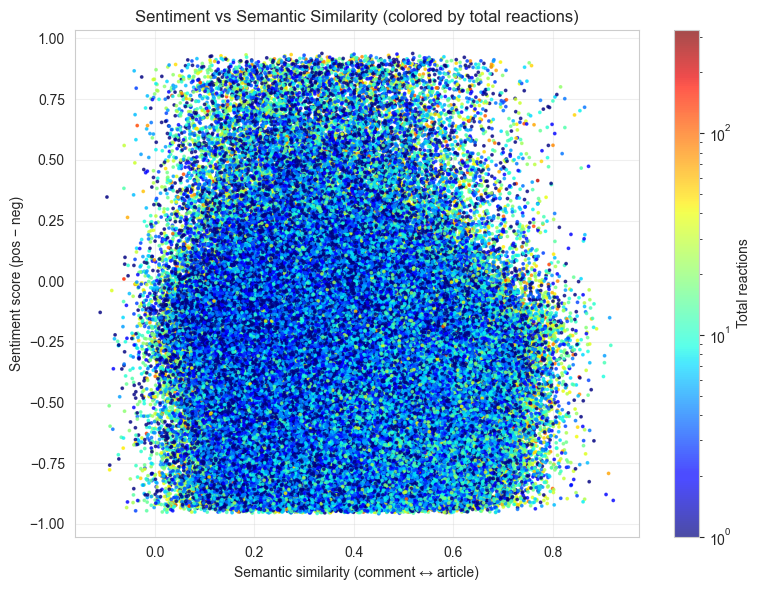

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

# -----------------------------
# File path
# -----------------------------
INPUT_CSV = CURSOR_DIR + "comment_sentiment_scores_all_extended_ssot.csv"

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(INPUT_CSV)

print(f"Total rows loaded: {len(df):,}")

# -----------------------------
# Filter valid comments
# -----------------------------
df_valid = df[
    (df["comment_before_publication"] == False) &
    (df["semantic_similarity"].notna())
]

print(f"Rows used for plotting: {len(df_valid):,}")

# -----------------------------
# Scatter plot (color by total_reactions)
# -----------------------------
plt.figure(figsize=(8, 6))

sc = plt.scatter(
    df_valid["semantic_similarity"],
    df_valid["sentiment_score"],

    c=df_valid["total_reactions"].clip(lower=1),
    norm=LogNorm(),

    # c=np.sqrt(df_valid["total_reactions"]),
    # vmin=0,
    # vmax=np.sqrt(df_valid["total_reactions"].quantile(0.99)),
    
    # c=df_valid["total_reactions"], 
    
    # c=np.log1p(df_valid["total_reactions"]),
    
    cmap="jet", # "hot" "coolwarm" "RdBu_r" "jet"
    s=3,
    alpha=0.7
)

plt.xlabel("Semantic similarity (comment ↔ article)")
plt.ylabel("Sentiment score (pos − neg)")
plt.title("Sentiment vs Semantic Similarity (colored by total reactions)")
plt.grid(True, alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
cbar = plt.colorbar(sc)
cbar.set_label("Total reactions")

plt.tight_layout()
plt.show()

C:\Users\tom\AppData\Local\Temp\ipykernel_9004\2554713682.py:16: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_CSV)


Total rows loaded: 320,196
Rows used for plotting: 308,243


C:\Users\tom\AppData\Local\Temp\ipykernel_9004\2554713682.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


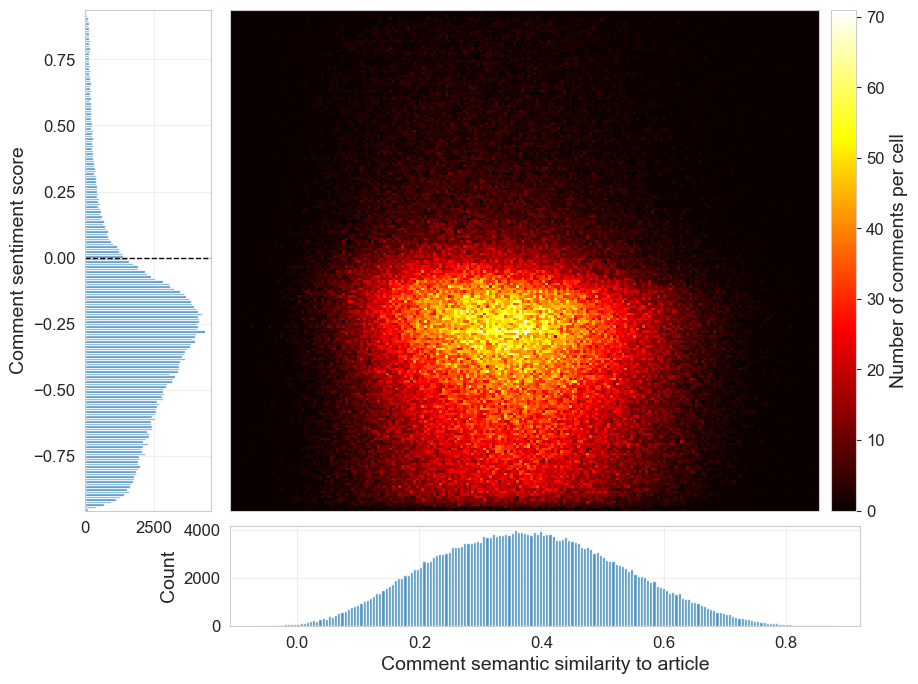

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

FZ = 12 # Font size
BINZ = 200
# -----------------------------
# File path
# -----------------------------
INPUT_CSV = CURSOR_DIR + "comment_sentiment_scores_all_extended_ssot.csv"

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(INPUT_CSV)

print(f"Total rows loaded: {len(df):,}")

# -----------------------------
# Filter valid comments
# -----------------------------
df_valid = df[
    (df["comment_before_publication"] == False) &
    (df["semantic_similarity"].notna())
]

print(f"Rows used for plotting: {len(df_valid):,}")

# ============================================================
# Create figure with GridSpec
# ============================================================
fig = plt.figure(figsize=(10, 8))

gs = GridSpec(
    nrows=2,
    ncols=2,
    width_ratios=[1, 5],
    height_ratios=[5, 1],
    wspace=0.05,
    hspace=0.05
)

# -----------------------------
# LEFT: Sentiment score distribution
# -----------------------------
ax_hist_y = fig.add_subplot(gs[0, 0])

ax_hist_y.hist(
    df_valid["sentiment_score"],
    bins=BINZ,
    orientation="horizontal",
    alpha=0.8
)

ax_hist_y.axhline(0, color="black", linestyle="--", linewidth=1)

# ax_hist_y.set_xlabel("Count")
ax_hist_y.set_ylabel("Comment sentiment score", fontsize=FZ+2)
# ax_hist_y.set_title("Sentiment distribution")
ax_hist_y.tick_params(axis="x", labelsize=FZ)
ax_hist_y.tick_params(axis="y", labelsize=FZ)
ax_hist_y.grid(True, alpha=0.3)

# -----------------------------
# RIGHT-TOP: 2D cumulative grid (100x100)
# -----------------------------
ax_heat = fig.add_subplot(gs[0, 1], sharey=ax_hist_y)

# Define grid size
GRID_SIZE = BINZ

# Compute 2D histogram
H, xedges, yedges = np.histogram2d(
    df_valid["semantic_similarity"],
    df_valid["sentiment_score"],
    bins=GRID_SIZE
)

# Plot cumulative density
mesh = ax_heat.pcolormesh(
    xedges,
    yedges,
    H.T,
    cmap="hot"
)

# ax_heat.set_xlabel("Semantic similarity (comment ↔ article)")
# ax_heat.set_title(
    # "Sentiment vs Semantic Similarity\n"
    # "(100×100 cumulative density)"
# )
ax_heat.grid(True, alpha=0.2)

# Hide duplicate y-axis labels
plt.setp(ax_heat.get_yticklabels(), visible=False)

# -----------------------------
# RIGHT-BOTTOM: Semantic similarity distribution
# -----------------------------
ax_hist_x = fig.add_subplot(gs[1, 1], sharex=ax_heat)

ax_hist_x.hist(
    df_valid["semantic_similarity"],
    bins=BINZ,
    alpha=0.8
)
# ax_hist_x.set_xlim(0, 1)   # <-- add this
ax_hist_x.set_xlabel("Comment semantic similarity to article", fontsize=FZ+2)
ax_hist_x.set_ylabel("Count", fontsize=FZ+2)
ax_hist_x.tick_params(axis="x", labelsize=FZ)
ax_hist_x.tick_params(axis="y", labelsize=FZ)
# ax_hist_x.set_title("Semantic similarity distribution")
ax_hist_x.grid(True, alpha=0.3)

# Hide x tick labels on heatmap
plt.setp(ax_heat.get_xticklabels(), visible=False)

# -----------------------------
# Colorbar (cumulative count)
# -----------------------------
cbar = fig.colorbar(
    mesh,
    ax=ax_heat,
    fraction=0.046,
    pad=0.02
)
cbar.set_label("Number of comments per cell", fontsize=FZ+2)
# Tick label font size (THIS is what you’re missing)
cbar.ax.tick_params(labelsize=FZ)

plt.tight_layout()
plt.show()

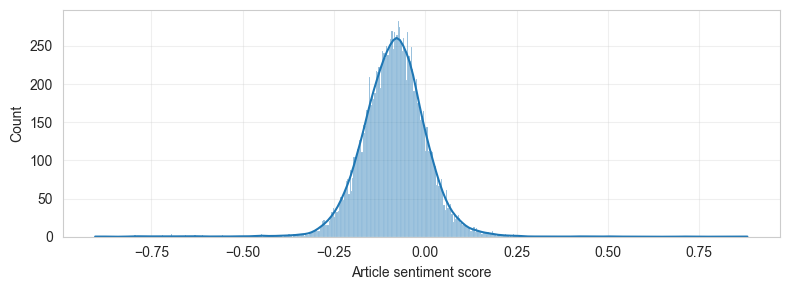

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

INPUT_CSV = CURSOR_DIR + "article_sentiment_scores_all_extended.csv"

# Load article sentiment scores
df = pd.read_csv(INPUT_CSV)

# Basic sanity check
df["article_sentiment_score"] = pd.to_numeric(
    df["article_sentiment_score"], errors="coerce"
)
# df["article_total_reactions"] = pd.to_numeric(
#     df["article_total_reactions"], errors="coerce"
# )
# df["comments_count"] = pd.to_numeric(
#     df["comments_count"], errors="coerce"
# )

# Plot distribution
plt.figure(figsize=(8, 3))
sns.histplot(
    df["article_sentiment_score"].dropna(),
    bins=500,
    kde=True
)
plt.xlabel("Article sentiment score")
plt.ylabel("Count")
# plt.title("Distribution of Article Sentiment Scores")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# # Plot distribution
# plt.figure(figsize=(8, 3))
# sns.histplot(
#     df["article_total_reactions"].dropna(),
#     bins=200,
#     kde=True
# )
# plt.xlabel("Article total reactions")
# plt.ylabel("Count")
# # plt.title("Distribution of Article Sentiment Scores")
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# # Plot distribution
# plt.figure(figsize=(8, 3))
# sns.histplot(
#     df["comments_count"].dropna(),
#     bins=200,
#     kde=True
# )
# plt.xlabel("Article comments count")
# plt.ylabel("Count")
# # plt.title("Distribution of Article Sentiment Scores")
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

C:\Users\tom\AppData\Local\Temp\ipykernel_9004\623220599.py:17: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_comment = pd.read_csv(COMMENT_CSV)


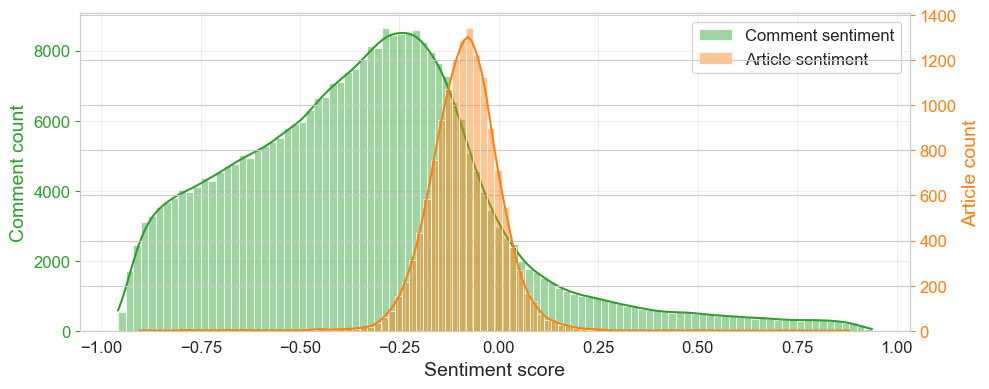

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FZ = 12  # Font size

# --------------------------------------------------
# INPUT FILES
# --------------------------------------------------
ARTICLE_CSV = CURSOR_DIR + "article_sentiment_scores_all_extended.csv"
COMMENT_CSV = CURSOR_DIR + "comment_sentiment_scores_all_extended_ssot.csv"

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
df_article = pd.read_csv(ARTICLE_CSV)
df_comment = pd.read_csv(COMMENT_CSV)

# Ensure numeric
df_article["article_sentiment_score"] = pd.to_numeric(
    df_article["article_sentiment_score"], errors="coerce"
)

df_comment["sentiment_score"] = pd.to_numeric(
    df_comment["sentiment_score"], errors="coerce"
)

# --------------------------------------------------
# PLOT (DUAL Y-AXIS)
# --------------------------------------------------
fig, ax_left = plt.subplots(figsize=(10, 4))
ax_right = ax_left.twinx()

# --- Comment sentiment (LEFT, BLUE) ---
sns.histplot(
    df_comment["sentiment_score"].dropna(),
    bins=100,
    kde=True,
    color="tab:green",
    stat="count",
    alpha=0.45,
    ax=ax_left,
    label="Comment sentiment"
)

# --- Article sentiment (RIGHT, RED) ---
sns.histplot(
    df_article["article_sentiment_score"].dropna(),
    bins=100,
    kde=True,
    color="tab:orange",
    stat="count",
    alpha=0.45,
    ax=ax_right,
    label="Article sentiment"
)

# --------------------------------------------------
# FORMATTING
# --------------------------------------------------
ax_left.set_xlabel("Sentiment score", fontsize=FZ + 2)

ax_left.set_ylabel("Comment count", fontsize=FZ + 2, color="tab:green")
ax_right.set_ylabel("Article count", fontsize=FZ + 2, color="tab:orange")

ax_left.tick_params(axis="x", labelsize=FZ)
ax_left.tick_params(axis="y", labelsize=FZ, colors="tab:green")
ax_right.tick_params(axis="y", labelsize=FZ, colors="tab:orange")

ax_left.grid(True, alpha=0.3)

# --------------------------------------------------
# COMBINED LEGEND
# --------------------------------------------------
handles_left, labels_left = ax_left.get_legend_handles_labels()
handles_right, labels_right = ax_right.get_legend_handles_labels()

ax_left.legend(
    handles_left + handles_right,
    labels_left + labels_right,
    fontsize=FZ,
    loc="upper right"
)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FZ = 12  # Font size

# --------------------------------------------------
# INPUT FILES
# --------------------------------------------------
ARTICLE_CSV = CURSOR_DIR + "article_sentiment_scores_all_extended.csv"

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
df_article = pd.read_csv(ARTICLE_CSV)

# Ensure numeric
df_article["article_sentiment_score"] = pd.to_numeric(
    df_article["article_sentiment_score"], errors="coerce"
)

df_article["sentiment_score_mean"] = pd.to_numeric(
    df_article["sentiment_score_mean"], errors="coerce"
)

# --------------------------------------------------
# PLOT (DUAL Y-AXIS)
# --------------------------------------------------
fig, ax_left = plt.subplots(figsize=(10, 4))
ax_right = ax_left.twinx()

# --- Comment sentiment (LEFT, BLUE) ---
sns.histplot(
    df_article["sentiment_score_mean"].dropna(),
    bins=60,
    kde=True,
    color="tab:blue",
    stat="count",
    alpha=0.45,
    ax=ax_left,
    label="Comment sentiment"
)

# --- Article sentiment (RIGHT, RED) ---
sns.histplot(
    df_article["article_sentiment_score"].dropna(),
    bins=60,
    kde=True,
    color="tab:red",
    stat="count",
    alpha=0.45,
    ax=ax_right,
    label="Article sentiment"
)

# --------------------------------------------------
# FORMATTING
# --------------------------------------------------
ax_left.set_xlabel("Sentiment score", fontsize=FZ + 2)

ax_left.set_ylabel("Comment count", fontsize=FZ + 2, color="tab:blue")
ax_right.set_ylabel("Article count", fontsize=FZ + 2, color="tab:red")

ax_left.tick_params(axis="x", labelsize=FZ)
ax_left.tick_params(axis="y", labelsize=FZ, colors="tab:blue")
ax_right.tick_params(axis="y", labelsize=FZ, colors="tab:red")

ax_left.grid(True, alpha=0.3)

# --------------------------------------------------
# COMBINED LEGEND
# --------------------------------------------------
handles_left, labels_left = ax_left.get_legend_handles_labels()
handles_right, labels_right = ax_right.get_legend_handles_labels()

ax_left.legend(
    handles_left + handles_right,
    labels_left + labels_right,
    fontsize=FZ,
    loc="upper right"
)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

FZ = 12  # Font size

# --------------------------------------------------
# INPUT FILE
# --------------------------------------------------
ARTICLE_CSV = CURSOR_DIR + "article_sentiment_scores_all_extended.csv"

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
df = pd.read_csv(ARTICLE_CSV)

# Ensure numeric
df["article_sentiment_score"] = pd.to_numeric(
    df["article_sentiment_score"], errors="coerce"
)
df["sentiment_score_mean"] = pd.to_numeric(
    df["sentiment_score_mean"], errors="coerce"
)

# Drop rows with missing values in either column
df = df.dropna(subset=["article_sentiment_score", "sentiment_score_mean"])

# --------------------------------------------------
# SORT BY ARTICLE SENTIMENT (DESCENDING)
# --------------------------------------------------
df_sorted = df.sort_values(
    by="article_sentiment_score",
    ascending=False
).reset_index(drop=True)

# X-axis = article rank
x = range(len(df_sorted))

# --------------------------------------------------
# PLOT
# --------------------------------------------------
plt.figure(figsize=(12, 5))

plt.plot(
    x,
    df_sorted["sentiment_score_mean"],
    color="tab:blue",
    linewidth=0.5,
    alpha=0.8,
    label="Mean comment sentiment score"
)

plt.plot(
    x,
    df_sorted["article_sentiment_score"],
    color="tab:red",
    linewidth=2,
    label="Article sentiment score"
)

# --------------------------------------------------
# FORMATTING
# --------------------------------------------------
plt.xlabel("Articles (sorted by article sentiment)", fontsize=FZ + 2)
plt.ylabel("Sentiment score", fontsize=FZ + 2)

plt.title(
    "Article Sentiment vs Mean Comment Sentiment\n"
    "(Articles sorted by article sentiment score)",
    fontsize=FZ + 2
)

plt.xticks(fontsize=FZ)
plt.yticks(fontsize=FZ)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=FZ)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# --------------------------------------------------
# CONFIG
# --------------------------------------------------
INPUT_FILE = CURSOR_DIR + "article_sentiment_scores_all_extended.csv"
FZ = 12  # Font size control

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
df = pd.read_csv(INPUT_FILE)

plot_df = df[
    [
        "article_sentiment_score",
        "sentiment_score_mean",
        # "injection_sentiment_score",
        "comments_count",
        "article_total_reactions",
        "neu_mean"
    ]
].dropna()

print("Rows used for plotting:", len(plot_df))

# --------------------------------------------------
# SCATTER PLOT
# --------------------------------------------------
plt.figure(figsize=(8, 6))

sc = plt.scatter(
    plot_df["article_sentiment_score"],
    plot_df["sentiment_score_mean"],
    c=plot_df["comments_count"], # comments_count | injection_sentiment_score
    norm=LogNorm(),
    cmap="viridis",
    s=20,
    alpha=0.7
)

# Colorbar for comments count
cbar = plt.colorbar(sc)
cbar.set_label("Comment count", fontsize=FZ+2)
cbar.ax.tick_params(labelsize=FZ)

# Reference line y = x
min_val = min(
    plot_df["article_sentiment_score"].min(),
    plot_df["sentiment_score_mean"].min()
)
max_val = max(
    plot_df["article_sentiment_score"].max(),
    plot_df["sentiment_score_mean"].max()
)

plt.plot([min_val, max_val], [min_val, max_val], "--", color="gray")

# --------------------------------------------------
# LABELS & FORMATTING
# --------------------------------------------------
plt.xlabel("Article sentiment score", fontsize=FZ + 2)
plt.ylabel("Per article mean comment sentiment score", fontsize=FZ + 2)

# plt.title(
#     "Article vs Comment Sentiment (Color = Comments Count)",
#     fontsize=FZ + 2
# )

plt.xticks(fontsize=FZ)
plt.yticks(fontsize=FZ)

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Run below snippet first
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
FZ = 12 # Font size

# Load data
tsne_df0 = pd.read_csv(CURSOR_DIR + "narrative_clusters_umap.csv") # tsne or umap
sent_df0 = pd.read_csv(CURSOR_DIR + "article_sentiment_scores_all_extended.csv")

# Merge on portal + article_id
df0 = tsne_df0.merge(
    sent_df0,
    on=["portal", "article_id"],
    how="inner"
)

# Ensure sentiment is numeric
df0["article_sentiment_score"] = pd.to_numeric(
    df0["article_sentiment_score"], errors="coerce"
)

# Ensure sentiment is numeric
df0["sentiment_score_mean"] = pd.to_numeric(
    df0["sentiment_score_mean"], errors="coerce"
)

# Ensure total reactions is numeric
df0["article_total_reactions"] = pd.to_numeric(
    df0["article_total_reactions"], errors="coerce"
)

# Ensure comments count is numeric
df0["comments_count"] = pd.to_numeric(
    df0["comments_count"], errors="coerce"
)

# Scatter plot
plt.figure(figsize=(9, 7))
sc = plt.scatter(
    df0["x"],
    df0["y"],
    c=df0["sentiment_score_mean"],
    # c=df0["article_total_reactions"],
    # c=df0["comments_count"],
    # c=np.log1p(df0["article_total_reactions"]),
    cmap="jet", # "hot" "coolwarm" "RdBu_r" "jet"
    # vmin=-0.6,
    # vmax=0.6,
    s=5,
    alpha=0.9
)
# ---- DRAW GRAY CONTOURS (CONVEX HULLS) ----
for cid in sorted(df["cluster_id"].unique()):
    if cid == -1:
        continue

    pts = df[df["cluster_id"] == cid][["x", "y"]].values
    if len(pts) < 10:
        continue

    hull = ConvexHull(pts)
    hull_pts = pts[hull.vertices]
    hull_pts = np.vstack([hull_pts, hull_pts[0]])  # close polygon

    plt.plot(
        hull_pts[:, 0],
        hull_pts[:, 1],
        color="gray",
        linewidth=1,
        alpha=0.99
    )

plt.xlabel("t-SNE 1", fontsize=FZ+2)
plt.ylabel("t-SNE 2", fontsize=FZ+2)
# plt.xlabel("UMAP-1", fontsize=FZ+2)
# plt.ylabel("UMAP-2", fontsize=FZ+2)
plt.tick_params(axis="x", labelsize=FZ)
plt.tick_params(axis="y", labelsize=FZ)
# plt.title("Narrative Clusters (t-SNE) Colored by Article Sentiment")

# Colorbar
cbar = plt.colorbar(sc)
# cbar.set_label("Article sentiment score", fontsize=FZ+2)
cbar.set_label("Per article mean comment sentiment score", fontsize=FZ)
# cbar.set_label("Article total reactions", fontsize=FZ+2)
# cbar.set_label("Article comments count", fontsize=FZ+2)
# Set tick label size
cbar.ax.tick_params(labelsize=FZ)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import HDBSCAN
from scipy.spatial import ConvexHull
import numpy as np

# ------------------------------------
# LOAD DATA
# ------------------------------------
df = pd.read_csv(CURSOR_DIR + "narrative_clusters_tsne.csv") # tsne umap

X = df[["x", "y"]].values

# ------------------------------------
# HDBSCAN (DENSITY ISLAND DETECTION)
# ------------------------------------
clusterer = HDBSCAN(
    min_cluster_size=230, # tsne=230 | umap=
    min_samples=1,
    cluster_selection_method="leaf"
)

df["cluster_id"] = clusterer.fit_predict(X)

n_clusters = len(set(df["cluster_id"])) - (1 if -1 in df["cluster_id"] else 0)
print("Clusters found:", n_clusters)

# ------------------------------------
# VISUALIZATION
# ------------------------------------
plt.figure(figsize=(10, 8))
ax = plt.gca()

sc = ax.scatter(
    df["x"],
    df["y"],
    c=df["cluster_id"],
    cmap="jet",
    s=8,
    alpha=0.9
)

# ---- DRAW GRAY CONTOURS (CONVEX HULLS) ----
for cid in sorted(df["cluster_id"].unique()):
    if cid == -1:
        continue

    pts = df[df["cluster_id"] == cid][["x", "y"]].values
    if len(pts) < 10:
        continue

    hull = ConvexHull(pts)
    hull_pts = pts[hull.vertices]
    hull_pts = np.vstack([hull_pts, hull_pts[0]])  # close polygon

    ax.plot(
        hull_pts[:, 0],
        hull_pts[:, 1],
        color="gray",
        linewidth=1.2,
        alpha=0.7
    )

# ------------------------------------
# FORMATTING
# ------------------------------------
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("Dense Narrative Islands (HDBSCAN on t-SNE)")

ax.grid(alpha=0.3)

cbar = plt.colorbar(sc)
cbar.set_label("Cluster ID (-1 = noise)")

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import HDBSCAN
from scipy.spatial import ConvexHull
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
tsne_df = pd.read_csv(CURSOR_DIR + "narrative_clusters_tsne.csv")
art_df = pd.read_csv(CURSOR_DIR + "article_sentiment_scores_all.csv")

# --------------------------------------------------
# CLUSTERING (AS YOU ALREADY DO)
# --------------------------------------------------
X = tsne_df[["x", "y"]].values

clusterer = HDBSCAN(
    min_cluster_size=200,
    min_samples=1,
    cluster_selection_method="leaf"
)

tsne_df["cluster_id"] = clusterer.fit_predict(X)

print(
    "Clusters found:",
    tsne_df["cluster_id"].nunique() - (1 if -1 in tsne_df["cluster_id"].values else 0)
)

# --------------------------------------------------
# MERGE TITLES
# --------------------------------------------------
df = tsne_df.merge(
    art_df[["article_id", "title"]],
    on="article_id",
    how="left"
)

df = df.dropna(subset=["title"])

# --------------------------------------------------
# LOAD SENTENCE TRANSFORMER
# --------------------------------------------------
model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

# --------------------------------------------------
# NAME EACH CLUSTER BY REPRESENTATIVE TITLE
# --------------------------------------------------
cluster_names = {}

for cid in sorted(df["cluster_id"].unique()):
    if cid == -1:
        continue

    titles = df.loc[df["cluster_id"] == cid, "title"].tolist()
    if len(titles) < 5:
        cluster_names[cid] = "Miscellaneous"
        continue

    embeddings = model.encode(
        titles,
        normalize_embeddings=True,
        batch_size=32
    )

    centroid = embeddings.mean(axis=0, keepdims=True)
    sims = cosine_similarity(embeddings, centroid).ravel()

    best_title = titles[sims.argmax()]

    # shorten title for plotting
    cluster_names[cid] = best_title[:80] + ("…" if len(best_title) > 80 else "")

# --------------------------------------------------
# VISUALIZATION WITH CONTOURS + LABELS
# --------------------------------------------------
plt.figure(figsize=(11, 9))
ax = plt.gca()

sc = ax.scatter(
    df["x"],
    df["y"],
    c=df["cluster_id"],
    cmap="tab20",
    s=8,
    alpha=0.85
)

# ---- DRAW CLUSTER CONTOURS + LABELS ----
for cid, name in cluster_names.items():
    pts = df[df["cluster_id"] == cid][["x", "y"]].values
    if len(pts) < 10:
        continue

    # Convex hull
    hull = ConvexHull(pts)
    hull_pts = pts[hull.vertices]
    hull_pts = np.vstack([hull_pts, hull_pts[0]])

    ax.plot(
        hull_pts[:, 0],
        hull_pts[:, 1],
        color="gray",
        linewidth=1.2,
        alpha=0.6
    )

    # Label at centroid
    cx, cy = pts.mean(axis=0)
    ax.text(
        cx,
        cy,
        name,
        fontsize=9,
        weight="bold",
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="gray",
            alpha=0.9
        )
    )

# --------------------------------------------------
# FORMATTING
# --------------------------------------------------
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("Narrative Clusters (t-SNE) with Automatic Cluster Names")

ax.grid(alpha=0.3)

cbar = plt.colorbar(sc)
cbar.set_label("Cluster ID (-1 = noise)")

plt.tight_layout()
plt.show()


KeyboardInterrupt: 

In [6]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
FILE = CURSOR_DIR + "emotion_shift_narrative_injection_extended.csv"
df = pd.read_csv(FILE)

# Ensure numeric
df["before"] = pd.to_numeric(df["before"], errors="coerce")
df["after"] = pd.to_numeric(df["after"], errors="coerce")

# Drop missing values
df = df.dropna(subset=["before", "after"])

# --------------------------------------------------
# SENTIMENT SHIFT
# --------------------------------------------------
df["delta"] = df["after"] - df["before"]

# --------------------------------------------------
# BASIC STATISTICS
# --------------------------------------------------
mean_before = df["before"].mean()
mean_after = df["after"].mean()
mean_shift = df["delta"].mean()
median_shift = df["delta"].median()

print("Mean sentiment before injection:", mean_before)
print("Mean sentiment after injection:", mean_after)
print("Mean sentiment shift:", mean_shift)
print("Median sentiment shift:", median_shift)

# --------------------------------------------------
# WILCOXON SIGNED-RANK TEST
# --------------------------------------------------
stat, p_value = wilcoxon(df["after"], df["before"])

print("\nWilcoxon signed-rank test")
print("Statistic:", stat)
print("p-value:", p_value)

# --------------------------------------------------
# EFFECT SIZE (OPTIONAL)
# --------------------------------------------------
effect_size = mean_shift / df["delta"].std()

print("\nEffect size (standardized mean shift):", effect_size)

# --------------------------------------------------
# SAMPLE SIZE
# --------------------------------------------------
print("\nNumber of discussions analyzed:", len(df))

Mean sentiment before injection: -0.3358408997679228
Mean sentiment after injection: -0.3358678219994168
Mean sentiment shift: -2.692223149394383e-05
Median sentiment shift: 0.003629019999999983

Wilcoxon signed-rank test
Statistic: 1220668.0
p-value: 0.4691131578393464

Effect size (standardized mean shift): -0.00020321562396187552

Number of discussions analyzed: 2229


In [9]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# absolute sentiment shift
df["abs_shift"] = df["delta"].abs()

# engagement column (adjust name if needed)
engagement_col = "article_total_reactions"   # or reactions / total_reactions

# Spearman correlation (robust for non-normal distributions)
rho, p = spearmanr(df[engagement_col], df["abs_shift"])

print("Spearman correlation between engagement and sentiment shift")
print("rho:", rho)
print("p-value:", p)

Spearman correlation between engagement and sentiment shift
rho: -0.19864829306173856
p-value: 2.8556806194409985e-21


In [10]:
from scipy.stats import mannwhitneyu

# split injections by engagement
median_engagement = df[engagement_col].median()

high = df[df[engagement_col] > median_engagement]["abs_shift"]
low = df[df[engagement_col] <= median_engagement]["abs_shift"]

stat, p = mannwhitneyu(high, low)

print("Median abs shift (low engagement):", low.median())
print("Median abs shift (high engagement):", high.median())
print("Mann-Whitney U p-value:", p)

Median abs shift (low engagement): 0.09315732999999997
Median abs shift (high engagement): 0.06668658
Mann-Whitney U p-value: 2.845734316914814e-14


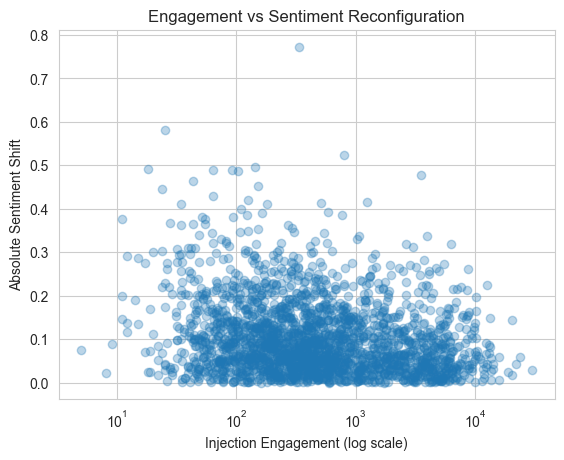

In [11]:
import matplotlib.pyplot as plt

plt.scatter(df[engagement_col], df["abs_shift"], alpha=0.3)
plt.xscale("log")
plt.xlabel("Injection Engagement (log scale)")
plt.ylabel("Absolute Sentiment Shift")
plt.title("Engagement vs Sentiment Reconfiguration")
plt.show()